predict the severity of Predict Stress_Level as Mild / Moderate / Severe using three different algorithm and compare them? identify which algorithm is more accurate?

Dataset Uploading from kaggle

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
Path='/content/drive/MyDrive/Colab Notebooks'

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sararazeen","key":"0ff39067dce207a3d8bf62adb21a1050"}'}

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d uom190346a/global-coffee-health-dataset

Dataset URL: https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset
License(s): CC0-1.0
  0% 0.00/184k [00:00<?, ?B/s]
100% 184k/184k [00:00<00:00, 439MB/s]


In [6]:
!unzip global-coffee-health-dataset.zip

Archive:  global-coffee-health-dataset.zip
  inflating: synthetic_coffee_health_10000.csv  


EDA

In [7]:
import pandas as pd
Raw_df = pd.read_csv("synthetic_coffee_health_10000.csv")
Raw_df.head(100)

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,18,Female,France,4.3,404.0,8.7,Excellent,28.4,79,Low,9.7,NaN,Other,0,0
96,97,38,Female,Netherlands,1.5,141.6,7.4,Good,28.2,64,Low,9.5,NaN,Healthcare,0,0
97,98,38,Female,France,4.9,465.6,7.1,Good,26.3,56,Low,3.6,NaN,Service,0,0
98,99,35,Female,Sweden,2.7,254.7,6.0,Good,28.8,69,Low,4.7,NaN,Service,0,0


In [8]:
Raw_df.isnull().sum()

,0
ID,0
Age,0
Gender,0
Country,0
Coffee_Intake,0
Caffeine_mg,0
Sleep_Hours,0
Sleep_Quality,0
BMI,0
Heart_Rate,0


In [9]:
Raw_df.dtypes

,0
ID,int64
Age,int64
Gender,object
Country,object
Coffee_Intake,float64
Caffeine_mg,float64
Sleep_Hours,float64
Sleep_Quality,object
BMI,float64
Heart_Rate,int64


In [10]:
import numpy as np

categorical_cols = [
    "Gender", "Country", "Sleep_Quality", "Stress_Level", "Health_Issues", "Occupation"]

numeric_cols = [ "ID", "Age", "Coffee_Intake", "Caffeine_mg", "Sleep_Hours", "BMI", "Heart_Rate", "Physical_Activity_Hours", "Smoking", "Alcohol_Consumption"]

for s in categorical_cols:
    Raw_df[s] = Raw_df[s].astype("category")

for n in numeric_cols:
    Raw_df[n] = Raw_df[n].astype("float")

display(Raw_df.dtypes)


,0
ID,float64
Age,float64
Gender,category
Country,category
Coffee_Intake,float64
Caffeine_mg,float64
Sleep_Hours,float64
Sleep_Quality,category
BMI,float64
Heart_Rate,float64


Unique values per column

In [11]:

for column in Raw_df.columns:
    try:
        unique_vals = np.unique(Raw_df[column])
    except:
        unique_vals = Raw_df[column].unique()

    nr_values = len(unique_vals)
    if nr_values < 10:
        print(f"{column} ({nr_values} values): {unique_vals}")
    else:
        print(f"{column} has {nr_values} unique values")

ID has 10000 unique values
Age has 59 unique values
Gender (3 values): ['Female' 'Male' 'Other']
Country has 20 unique values
Coffee_Intake has 78 unique values
Caffeine_mg has 4277 unique values
Sleep_Hours has 71 unique values
Sleep_Quality (4 values): ['Excellent' 'Fair' 'Good' 'Poor']
BMI has 220 unique values
Heart_Rate has 58 unique values
Stress_Level (3 values): ['High' 'Low' 'Medium']
Physical_Activity_Hours has 151 unique values
Health_Issues (4 values): [NaN, 'Mild', 'Moderate', 'Severe']
Categories (3, object): ['Mild', 'Moderate', 'Severe']
Occupation (5 values): ['Healthcare' 'Office' 'Other' 'Service' 'Student']
Smoking (2 values): [0. 1.]
Alcohol_Consumption (2 values): [0. 1.]


In [12]:
print("Shape:", Raw_df.shape)

Shape: (10000, 16)


Data Cleaning or Data preprocessing

Drop "ID" column becuse it does not have any predictive power

In [15]:
if 'ID' in Raw_df.columns:
    Raw_df = Raw_df.drop(columns=['ID'])

n_dups = Raw_df.duplicated().sum()
print("Exact duplicate rows:", n_dups)
if n_dups > 0:
    Raw_df = Raw_df.drop_duplicates()
Raw_df.head(100)

Exact duplicate rows: 0


,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,40.0,Male,Germany,3.5,328.1,7.5,Good,24.9,78.0,Low,14.5,NaN,Other,0.0,0.0
1,33.0,Male,Germany,1.0,94.1,6.2,Good,20.0,67.0,Low,11.0,NaN,Service,0.0,0.0
2,42.0,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59.0,Medium,11.2,Mild,Office,0.0,0.0
3,53.0,Male,Germany,2.6,249.2,7.3,Good,24.7,71.0,Low,6.6,Mild,Other,0.0,0.0
4,32.0,Female,Spain,3.1,298.0,5.3,Fair,24.1,76.0,Medium,8.5,Mild,Student,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,18.0,Female,France,4.3,404.0,8.7,Excellent,28.4,79.0,Low,9.7,NaN,Other,0.0,0.0
96,38.0,Female,Netherlands,1.5,141.6,7.4,Good,28.2,64.0,Low,9.5,NaN,Healthcare,0.0,0.0
97,38.0,Female,France,4.9,465.6,7.1,Good,26.3,56.0,Low,3.6,NaN,Service,0.0,0.0
98,35.0,Female,Sweden,2.7,254.7,6.0,Good,28.8,69.0,Low,4.7,NaN,Service,0.0,0.0


In [20]:
cat_cols = ["Gender","Country","Sleep_Quality","Stress_Level","Health_Issues","Occupation"]
for c in cat_cols:

    Raw_df[c] = Raw_df[c].astype(str).str.strip().str.title()
    Raw_df.loc[Raw_df[c].isin(['Nan','None','']) , c] = np.nan


# for c in cat_cols:
#     # Only apply to object/category columns
#     if Raw_df[c].dtype == "object":
#         Raw_df[c] = Raw_df[c].str.strip().str.title()
#         Raw_df.loc[Raw_df[c].isin(['Nan','None','']), c] = np.nan


Handling missing data

In [21]:

missing_pct = Raw_df.isnull().mean().sort_values(ascending=False)
print(missing_pct)

# Health_Issues (5941 missing) -> create missing flag and fill with 'Unknown'
Raw_df['Health_Issues_missing'] = Raw_df['Health_Issues'].isna().astype(int)
Raw_df['Health_Issues'] = Raw_df['Health_Issues'].fillna('NaN')

# If very few numeric nulls exist, we'll impute later in pipeline (median)
# If any categorical nulls remain, fill with 'Unknown' now:
for c in ['Gender','Country','Sleep_Quality','Occupation','Stress_Level']:
    if Raw_df[c].isnull().sum() > 0:
        Raw_df[c] = Raw_df[c].fillna('Unknown')


Health_Issues              0.5941
Age                        0.0000
Country                    0.0000
Gender                     0.0000
Caffeine_mg                0.0000
Sleep_Hours                0.0000
Sleep_Quality              0.0000
Coffee_Intake              0.0000
BMI                        0.0000
Heart_Rate                 0.0000
Stress_Level               0.0000
Physical_Activity_Hours    0.0000
Occupation                 0.0000
Smoking                    0.0000
Alcohol_Consumption        0.0000
Health_Issues_missing      0.0000
dtype: float64


In above it is clear that Heath_Issues has missing values at around 59%

In [22]:
from sklearn.model_selection import train_test_split

# 1. Split train/test
X = Raw_df.drop(columns=['Stress_Level'])
y = Raw_df['Stress_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8000, 15)
Test shape: (2000, 15)


Categorical features like "Male", "Female", "Other", "Excellent", "Good", "Poor"must be converted into numeric form.

In [23]:
from sklearn.preprocessing import LabelEncoder

target_le = LabelEncoder()
Raw_df['Stress_Level'] = target_le.fit_transform(Raw_df['Stress_Level'])

Encode Stress_Level (target) with LabelEncoder becuase we are predicting Stress_Level

In [24]:
# Tree models: Label Encoding
from sklearn.preprocessing import LabelEncoder

tree_df = Raw_df.copy()
label_encoders = {}
for col in ['Gender','Country','Sleep_Quality','Health_Issues','Occupation']:
    le = LabelEncoder()
    tree_df[col] = le.fit_transform(tree_df[col])
    label_encoders[col] = le


In [25]:
# Linear models: One-Hot Encoding
linear_df = pd.get_dummies(
    Raw_df,
    columns=['Gender','Country','Sleep_Quality','Health_Issues','Occupation'],
    drop_first=True
)

ML algorithms that rely on distance get biased if one feature has a larger scale than others.The large-scale feature will dominate learning unless we scale them.

Tree based models do not require scaling, because they split on thresholds and don’t care about magnitude.

Outlier detection/handling (on train data set only) because test set should reflect real unseen data.

In [26]:
Raw_df

,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,Health_Issues_missing
0,40.0,Male,Germany,3.5,328.1,7.5,Good,24.9,78.0,1,14.5,NaN,Other,0.0,0.0,1
1,33.0,Male,Germany,1.0,94.1,6.2,Good,20.0,67.0,1,11.0,NaN,Service,0.0,0.0,1
2,42.0,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59.0,2,11.2,Mild,Office,0.0,0.0,0
3,53.0,Male,Germany,2.6,249.2,7.3,Good,24.7,71.0,1,6.6,Mild,Other,0.0,0.0,0
4,32.0,Female,Spain,3.1,298.0,5.3,Fair,24.1,76.0,2,8.5,Mild,Student,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50.0,Female,Japan,2.1,199.8,6.0,Fair,30.5,50.0,2,10.1,Moderate,Healthcare,0.0,1.0,0
9996,18.0,Female,Uk,3.4,319.2,5.8,Fair,19.1,71.0,2,11.6,Mild,Service,0.0,0.0,0
9997,26.0,Male,China,1.6,153.4,7.1,Good,25.1,66.0,1,13.7,NaN,Student,1.0,1.0,1
9998,40.0,Female,Finland,3.4,327.1,7.0,Good,19.3,80.0,1,0.1,NaN,Student,0.0,0.0,1


In [27]:
['Age','Coffee_Intake','Caffeine_mg','Sleep_Hours',
 'BMI','Heart_Rate','Physical_Activity_Hours']

['Age',
 'Coffee_Intake',
 'Caffeine_mg',
 'Sleep_Hours',
 'BMI',
 'Heart_Rate',
 'Physical_Activity_Hours']

In [28]:
import pandas as pd

# Combine X_train with y_train to analyze relationship
train_df = X_train.copy()
train_df['Stress_Level'] = y_train

numeric_cols = ['Age','Coffee_Intake','Caffeine_mg','Sleep_Hours',
                'BMI','Heart_Rate','Physical_Activity_Hours']

# See average value of each numeric feature by Stress_Level
for col in numeric_cols:
    print(f"\n{col} by Stress_Level:")
    print(train_df.groupby('Stress_Level')[col].mean())



Age by Stress_Level:
Stress_Level
High      34.975293
Low       34.988553
Medium    34.535366
Name: Age, dtype: float64

Coffee_Intake by Stress_Level:
Stress_Level
High      2.991808
Low       2.368574
Medium    2.748780
Name: Coffee_Intake, dtype: float64

Caffeine_mg by Stress_Level:
Stress_Level
High      284.242133
Low       225.030603
Medium    261.275000
Name: Caffeine_mg, dtype: float64

Sleep_Hours by Stress_Level:
Stress_Level
High      4.455007
Low       7.243463
Medium    5.570122
Name: Sleep_Hours, dtype: float64

BMI by Stress_Level:
Stress_Level
High      24.015735
Low       23.947737
Medium    23.927195
Name: BMI, dtype: float64

Heart_Rate by Stress_Level:
Stress_Level
High      71.219766
Low       70.416383
Medium    71.362805
Name: Heart_Rate, dtype: float64

Physical_Activity_Hours by Stress_Level:
Stress_Level
High      7.753446
Low       7.467322
Medium    7.412805
Name: Physical_Activity_Hours, dtype: float64


In [29]:
# import numpy as np

# col = "Age"   # 👈 change this to any numeric column in your dataset

# Q1 = X_train[col].quantile(0.25)
# Q3 = X_train[col].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# outliers = X_train[(X_train[col] < lower) | (X_train[col] > upper)]

# print(f"Column: {col}")
# print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
# print(f"Outliers found: {outliers.shape[0]}")
# outliers.head()



import numpy as np

# Features strongly linked to Stress_Level
important_features = ['Sleep_Hours', 'Coffee_Intake', 'Caffeine_mg']

for col in important_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[col] < lower) | (X_train[col] > upper)]

    print(f"\nColumn: {col}")
    print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    print(f"Outliers found: {outliers.shape[0]}")
    print(outliers[[col]].head())  # show first few outliers



Column: Sleep_Hours
Lower bound: 3.25, Upper bound: 10.05
Outliers found: 19
      Sleep_Hours
3973          3.1
1901          3.0
686           3.0
3562          3.0
6302          3.1

Column: Coffee_Intake
Lower bound: -1.50, Upper bound: 6.50
Outliers found: 36
      Coffee_Intake
124             7.6
6686            6.9
4110            7.3
2903            7.0
2276            6.7

Column: Caffeine_mg
Lower bound: -150.45, Upper bound: 621.35
Outliers found: 37
      Caffeine_mg
3517        621.4
124         722.4
6686        657.7
4110        693.8
2903        663.8


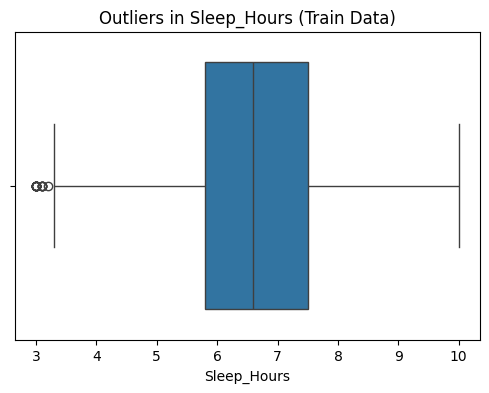

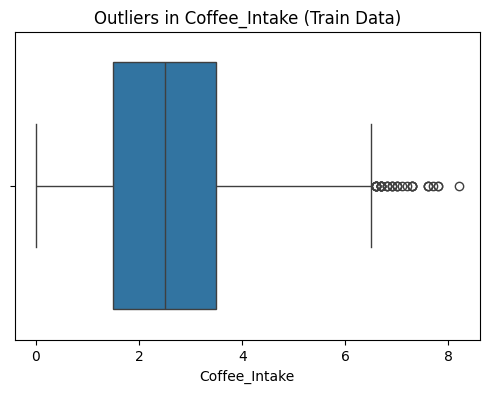

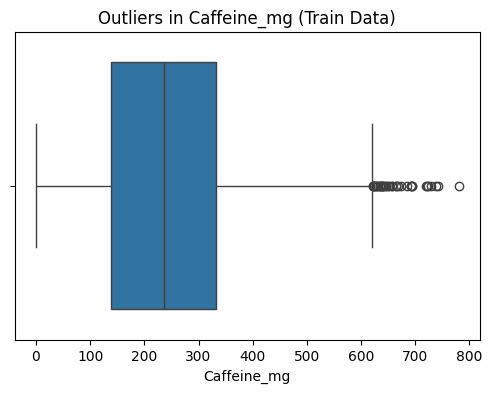

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

important_features = ['Sleep_Hours', 'Coffee_Intake', 'Caffeine_mg']

for col in important_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=X_train[col])
    plt.title(f"Outliers in {col} (Train Data)")
    plt.show()


Two versions of the dataset is used because different types of models (linear/tree) handle outliers differently

In [31]:
# Define bounds from IQR
bounds = {
    'Sleep_Hours': (3.25, 10.05),
    'Coffee_Intake': (-1.5, 6.5),
    'Caffeine_mg': (-150.45, 621.35)
}

# Version for Linear Models (clip Coffee_Intake & Caffeine_mg)
X_train_linear = X_train.copy()
X_test_linear = X_test.copy()

for col, (lower, upper) in bounds.items():
    if col != 'Sleep_Hours':   # don't clip Sleep_Hours
        X_train_linear[col] = X_train_linear[col].clip(lower, upper)
        X_test_linear[col] = X_test_linear[col].clip(lower, upper)

# Version for Tree Models (keep raw values)
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()


In [32]:
X = train_df.drop('Stress_Level', axis=1)
y = train_df['Stress_Level']

data encoding

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# ---- Tree Models: Label Encoding ----
tree_df = Raw_df.copy()
label_encoders = {}
for col in ['Gender','Country','Sleep_Quality','Health_Issues','Occupation']:
    le = LabelEncoder()
    tree_df[col] = le.fit_transform(tree_df[col])
    label_encoders[col] = le

X_tree = tree_df.drop('Stress_Level', axis=1)
y_tree = tree_df['Stress_Level']
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42, stratify=y_tree
)


linear_df = pd.get_dummies(
    Raw_df,
    columns=['Gender','Country','Sleep_Quality','Health_Issues','Occupation'],
    drop_first=True
)
X_linear = linear_df.drop('Stress_Level', axis=1)
y_linear = linear_df['Stress_Level']
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42, stratify=y_linear
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_lin = scaler.fit_transform(X_train_lin)
X_test_lin = scaler.transform(X_test_lin)


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# ---- Tree Models: Label Encoding ----
tree_df = Raw_df.copy()
label_encoders = {}
for col in ['Gender','Country','Sleep_Quality','Health_Issues','Occupation']:
    le = LabelEncoder()
    tree_df[col] = le.fit_transform(tree_df[col])
    label_encoders[col] = le

X_tree = tree_df.drop('Stress_Level', axis=1)
y_tree = tree_df['Stress_Level']
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42, stratify=y_tree
)

# ---- Logistic Regression: One-Hot Encoding ----
linear_df = pd.get_dummies(
    Raw_df,
    columns=['Gender','Country','Sleep_Quality','Health_Issues','Occupation'],
    drop_first=True
)
X_linear = linear_df.drop('Stress_Level', axis=1)
y_linear = linear_df['Stress_Level']
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42, stratify=y_linear
)

# ---- Scaling for Logistic Regression ----
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_lin = scaler.fit_transform(X_train_lin)
X_test_lin = scaler.transform(X_test_lin)


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_lin, y_train_lin)
y_pred_lr = lr.predict(X_test_lin)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_tree, y_train_tree)
y_pred_dt = dt.predict(X_test_tree)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tree, y_train_tree)
y_pred_rf = rf.predict(X_test_tree)


Accuracy Scores:
Logistic Regression: 1.000
Decision Tree:       1.000
Random Forest:       1.000


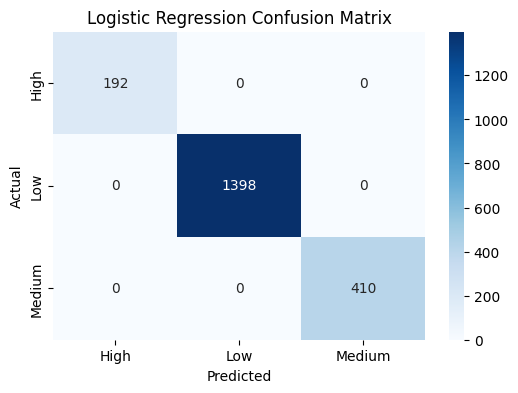

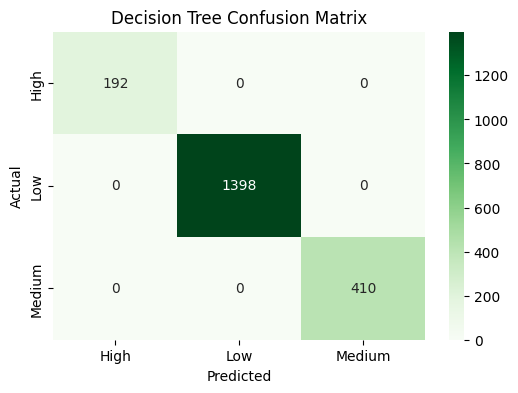

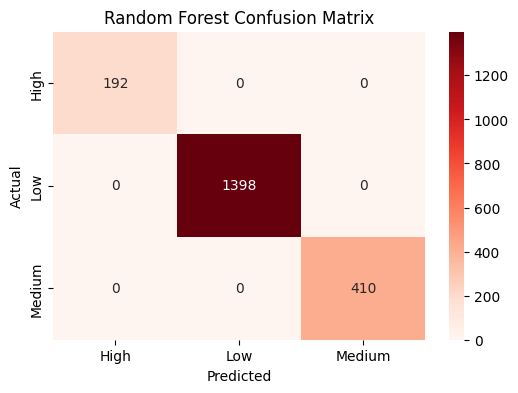

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Compute accuracy scores with correct y_test
acc_lr = accuracy_score(y_test_lin, y_pred_lr)
acc_dt = accuracy_score(y_test_tree, y_pred_dt)
acc_rf = accuracy_score(y_test_tree, y_pred_rf)

print("Accuracy Scores:")
print(f"Logistic Regression: {acc_lr:.3f}")
print(f"Decision Tree:       {acc_dt:.3f}")
print(f"Random Forest:       {acc_rf:.3f}")

# Get class labels from the LabelEncoder
labels = target_le.classes_

# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test_lin, y_pred_lr, labels=range(len(labels)))
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test_tree, y_pred_dt, labels=range(len(labels)))
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test_tree, y_pred_rf, labels=range(len(labels)))
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels,
            yticklabels=labels)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# # 📊 Compare model accuracies side by side
# plt.figure(figsize=(6,4))
# sns.barplot(x=["LogReg", "Decision Tree", "Random Forest"],
#             y=[acc_lr, acc_dt, acc_rf])
# plt.title("Model Accuracy Comparison")
# plt.ylabel("Accuracy")
# plt.ylim(0,1)
# plt.show()


/tmp/ipython-input-3920502565.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette=['blue','green','red'])


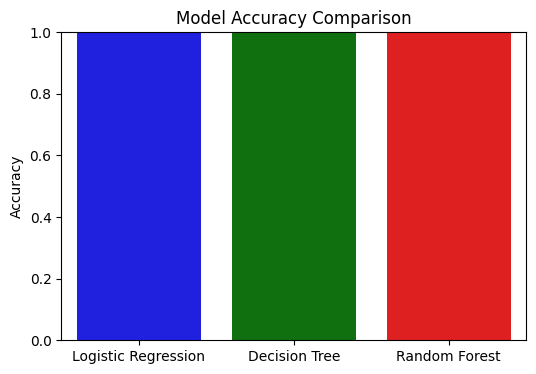

In [ ]:
# 📊 Compare model accuracies side by side
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [acc_lr, acc_dt, acc_rf]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies, palette=['blue','green','red'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0,1)
plt.show()
